# Kritisk vej-planlægning af en bilforsikringslancering

## Sammenfatning for ledelsen

Lancering af et privat bilforsikringsprodukt er et tværfagligt program: aktuarer prissætter risikoen, compliance indsender takster til myndigheden og afventer godkendelse, IT konfigurerer policeadministrationssystemet, og distributionen uddanner agenter. Disse opgaver har hårde forudsætningsrelationer, så lanceringsdatoen fastlægges af den længste afhængige kæde gennem planen -- den **kritiske vej**.

Denne notebook opbygger et Activity-on-Node-projektnetværk med elleve lanceringsopgaver og beregner en fuld **Critical Path Method (CPM)**-plan med **PROC OPTMODEL**. CPM's fremadrettede og bagudrettede gennemløb er lineære programmer over forudsætningsgrafen: det fremadrettede gennemløb (længste vej fra starten) giver hver opgaves tidligste start og afslutning, og et bagudrettet længste vej-gennemløb giver den seneste start og afslutning samt den **samlede flydetid** (planslæk). Resultaterne nedenfor er udelukkende frembragt af koden i denne notebook -- hvert tal i teksten er læst tilbage fra det udførte output.

**Hvad planen viser.** På en femdages arbejdskalender forankret ved 01JUN2026 spænder programmet over **97 arbejdsdage** og afsluttes **13OCT2026**. Ni af de elleve opgaver ligger på den kritiske vej (Kickoff -> Markedsundersøgelse -> Samling af tabsdata -> Prissætning -> Systemdesign -> Systemopbygning -> UAT -> Agentuddannelse -> Lancering) og bærer nul flydetid. Kun den regulatoriske gren -- **takstindsendelse** og **godkendelse** -- har slæk: hver kan skride op til **30 arbejdsdage** uden at rykke lanceringen, fordi den parallelle systemopbygningsgren er den længste af de to konvergerende veje.

## Sådan er den bygget

CPM er klassisk en SAS/OR-procedure, men dens kerneberegning er et par længste vej-problemer på forudsætningsgrafen, som PROC OPTMODEL udtrykker direkte som små lineære programmer:

- **Fremadrettet gennemløb (tidligste tider).** Minimér de tidligste start-variabler underlagt `ES[successor] >= ES[predecessor] + duration + lag` for hver forudsætningsbue. I optimum svarer hvert `ES` til den længste vej fra projektstarten, altså det tidligste tidspunkt opgaven kan begynde.
- **Bagudrettet gennemløb (seneste tider / flydetid).** Beregn for hver opgave den længste resterende vej til projektslut (`TAIL`). Den seneste start er da `makespan - TAIL`, og **samlet flydetid** er `sen start - tidlig start`. Opgaver med nul flydetid er kritiske.

Netværket, varighederne, forudsætnings-lags og de opgavevise ressourcebehov genereres alle inline; der er ingen eksterne input. Kalenderdatoer på arbejdsdage udledes med `INTNX('weekday', ...)`, så weekender springes over.

## Data

| Datasæt | Rækker | Nøglevariabler | Beskrivelse |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Aktivitetsmaster: hver lanceringsopgave, dens varighed i arbejdsdage og det daglige antal aktuarer/udviklere, den kræver |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Forudsætningsbuer i Activity-on-Node-netværket; `lag` er en finish-to-start-forsinkelse i arbejdsdage (den regulatoriske ventetid efter godkendelse) |

Numeriske aktivitets-id'er indekserer netværket, så forudsætningsgrafen læses rent ind i OPTMODEL's tuple-mængde; de læsbare `activity`-navne flettes bagefter tilbage på planen.

In [1]:
data acts;
   LÆNGDE activity $24;
   INDDATA id activity $ dur actuary developer;
   DATALINES;
1 Kickoff              3 1 0
2 Markedsundersøgelse  8 2 0
3 Tabsdatasamling     10 3 0
4 Prissætning          9 3 1
5 Takstindsendelse     4 1 0
6 Godkendelse          6 1 0
7 Systemdesign        12 1 2
8 Systemopbygning     18 0 3
9 UAT                 15 0 2
10 Agentuddannelse    20 1 1
11 Lancering           2 1 1
;
KØR;

data arcs;
   INDDATA pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
KØR;

/* rent numerisk visning af varigheder til OPTMODEL */
data acts_n; SÆT acts; BEHOLD id dur; KØR;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Fremadrettet gennemløb -- tidligste start og afslutning

Det fremadrettede gennemløb er et længste vej-LP. Betingelsen `ES[j] >= ES[i] + dur[i] + lag[i,j]` for hver bue tvinger hver opgave til at starte tidligst når alle dens forudsætninger er afsluttet (plus et eventuelt regulatorisk lag); ved at minimere de tidligste start-variabler drives hver til sin længste forudsætningsvej. Vi skriver de løste `ES`-værdier direkte fra OPTMODEL-variablen til `fwd`.

In [2]:
PROCEDURE optmodel;
   SÆT NODES; num dur{NODES};
   READ data acts_n INTO NODES=[id] dur=dur;

   SÆT <num,num> ARCS; num lag{ARCS};
   READ data arcs INTO ARCS=[pred succ] lag=lag;

   VARIABEL ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREATE data fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Bagudrettet gennemløb -- seneste tider og samlet flydetid

`TAIL[a]` er den længste vej fra opgave `a` videre til projektslut, så den skal dække opgavens egen varighed og, for hver efterfølger, laggen plus efterfølgerens tail: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Ved at minimere tails opnås de strammeste sådanne værdier. Projektets **makespan** er den største tidlige afslutning; hver opgaves **sene start** er `makespan - TAIL`, og **samlet flydetid** er `sen start - tidlig start`. En flydetid på nul markerer den kritiske vej.

In [3]:
PROCEDURE optmodel;
   SÆT NODES; num dur{NODES};
   READ data acts_n INTO NODES=[id] dur=dur;

   SÆT <num,num> ARCS; num lag{ARCS};
   READ data arcs INTO ARCS=[pred succ] lag=lag;

   VARIABEL TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREATE data bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Saml planen og kalenderen

Vi fletter de tidlige starter og tails tilbage på aktivitetsmasteren, udleder den sene start/afslutning og samlet flydetid, og afbilder arbejdsdags-forskydningerne på kalenderdatoer med `INTNX('weekday', ...)`, så datoerne falder på hverdage. En opgave markeres som **kritisk**, når dens samlede flydetid er nul.

In [4]:
%LET anchor = '01jun2026'd;

data sched0;
   SAMMENFLET acts fwd bwd; EFTER id;
   ef = es + dur;            /* tidlig afslutning */
KØR;

PROCEDURE GENNEMSNIT data=sched0 NOPRINT;
   UDDATA out=mk(FJERN=_type_ _freq_) MAX(ef)=makespan;
KØR;

data sched;
   HVIS _n_=1 SÅ SÆT mk;
   SÆT sched0;
   BEHOLD_VÆRDI mspan;
   HVIS _n_=1 SÅ mspan = makespan;
   ls = mspan - tail;        /* sen start       */
   lf = ls + dur;            /* sen afslutning  */
   tfloat = ls - es;         /* samlet flydetid */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LÆNGDE cclass $10;
   HVIS critical SÅ cclass='Critical';
   ELLERS cclass='Float';
   format e_start e_finish l_start l_finish date9.;
KØR;

PROCEDURE SORTER data=sched out=sched_es; EFTER es id; KØR;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## CPM-planen

Tidlig/sen start og afslutning er angivet i arbejdsdage fra forankringen 01JUN2026 (dag 0). Opgaver i klassen **Critical** har nul samlet flydetid.

In [5]:
TITEL 'CPM-plan -- arbejdsdagstider og samlet flydetid';
PROCEDURE UDSKRIV data=sched_es noobs MÆRKAT;
   VARIABEL activity dur es ef ls lf tfloat cclass;
   MÆRKAT activity='Aktivitet' dur='Varighed(ad)' es='Tidlig start' ef='Tidlig afsl.'
         ls='Sen start' lf='Sen afsl.' tfloat='Samlet flydetid' cclass='Klasse';
KØR;

                                    CPM-plan -- arbejdsdagstider og samlet flydetid                                     


           Aktivitet  Varighed(ad)  Tidlig start  Tidlig afsl.  Sen start  Sen afsl.  Samlet flydetid    Klasse
--------------------  ------------  ------------  ------------  ---------  ---------  ---------------  --------
Kickoff                          3             0             3          0          3                0  Critical
Markedsundersøgelse              8             3            11          3         11                0  Critical
Tabsdatasamling                 10            11            21         11         21                0  Critical
Prissætning                      9            21            30         21         30                0  Critical
Takstindsendelse                 4            30            34         60         64               30  Float
Systemdesign                    12            30            42         30         42            


NOTE: Option TITLE changed to CPM-plan -- arbejdsdagstider og samlet flydetid.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


Kolonnen for tidlig start følger den afhængige kæde: Kickoff begynder på dag 0, og hver efterfølgende opgave starter, når dens forudsætninger er afsluttet. Projektet afsluttes ved den største tidlige afslutning.

## Den kritiske vej

Ved kun at liste opgaverne med nul flydetid, sammen med deres kalenderdatoer, fremkommer den kæde, der fastlægger lanceringsdatoen. Ethvert skrid på disse opgaver rykker lanceringen dag for dag.

In [6]:
TITEL 'Kritisk vej (samlet flydetid = 0) med kalenderdatoer';
PROCEDURE UDSKRIV data=sched_es noobs MÆRKAT;
   HVOR critical=1;
   VARIABEL activity dur e_start e_finish;
   MÆRKAT activity='Aktivitet' dur='Varighed(ad)'
         e_start='Tidlig start' e_finish='Tidlig afslutning';
KØR;

data mkrep;
   SÆT mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   format anchor FINISH date9.;
KØR;
TITEL 'Projektets varighed';
PROCEDURE UDSKRIV data=mkrep noobs MÆRKAT;
   VARIABEL anchor makespan FINISH;
   MÆRKAT anchor='Forankring (dag 0)'
         makespan='Makespan (arbejdsdage)'
         FINISH='Forventet afslutning';
KØR;

                                  Kritisk vej (samlet flydetid = 0) med kalenderdatoer                                  


           Aktivitet  Varighed(ad)  Tidlig start  Tidlig afslutning
--------------------  ------------  ------------  -----------------
Kickoff                          3     01JUN2026          03JUN2026
Markedsundersøgelse              8     04JUN2026          15JUN2026
Tabsdatasamling                 10     16JUN2026          29JUN2026
Prissætning                      9     30JUN2026          10JUL2026
Systemdesign                    12     13JUL2026          28JUL2026
Systemopbygning                 18     29JUL2026          21AUG2026
UAT                             15     24AUG2026          11SEP2026
Agentuddannelse                 20     14SEP2026          09OCT2026
Lancering                        2     12OCT2026          13OCT2026

                                                  Projektets varighed                                                   


Foran


NOTE: Option TITLE changed to Kritisk vej (samlet flydetid = 0) med kalenderdatoer.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Projektets varighed.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Hvor slækket ligger

De ikke-kritiske opgaver er den regulatoriske gren. Deres sene start/afslutning viser, hvor langt hver kan flytte sig, før den ville begynde at skubbe lanceringen. Fri flydetid er her lig samlet flydetid, fordi ingen anden opgave afhænger af dem, før de igen mødes ved agentuddannelsen.

In [7]:
TITEL 'Ikke-kritiske aktiviteter og deres planslæk';
PROCEDURE UDSKRIV data=sched_es noobs MÆRKAT;
   HVOR critical=0;
   VARIABEL activity dur e_start e_finish l_start l_finish tfloat;
   MÆRKAT activity='Aktivitet' dur='Varighed(ad)'
         e_start='Tidlig start' e_finish='Tidlig afslutning'
         l_start='Sen start' l_finish='Sen afslutning'
         tfloat='Samlet flydetid';
KØR;

                                      Ikke-kritiske aktiviteter og deres planslæk                                       


       Aktivitet  Varighed(ad)  Tidlig start  Tidlig afslutning  Sen start  Sen afslutning  Samlet flydetid
----------------  ------------  ------------  -----------------  ---------  --------------  ---------------
Takstindsendelse             4     13JUL2026          16JUL2026  24AUG2026       27AUG2026               30
Godkendelse                  6     17JUL2026          24JUL2026  28AUG2026       04SEP2026               30




NOTE: Option TITLE changed to Ikke-kritiske aktiviteter og deres planslæk.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Planens vandfald

En high-low-søjle pr. opgave, tegnet fra dens tidlige start til dens tidlige afslutning i projektrækkefølge, giver et Gantt-agtigt vandfald af planen. Hver søjles højde er opgavens varighed, og trappen stiger op til de 97 arbejdsdages makespan. Opgaver, der ligger *under* den stigende diagonal -- hvor toppen af en søjle er lavere end bunden af den næste søjle -- er dem med slæk.

                                  Bilforsikringslancering -- vandfald for tidlig plan                                   




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Bilforsikringslancering -- vandfald for tidlig plan.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


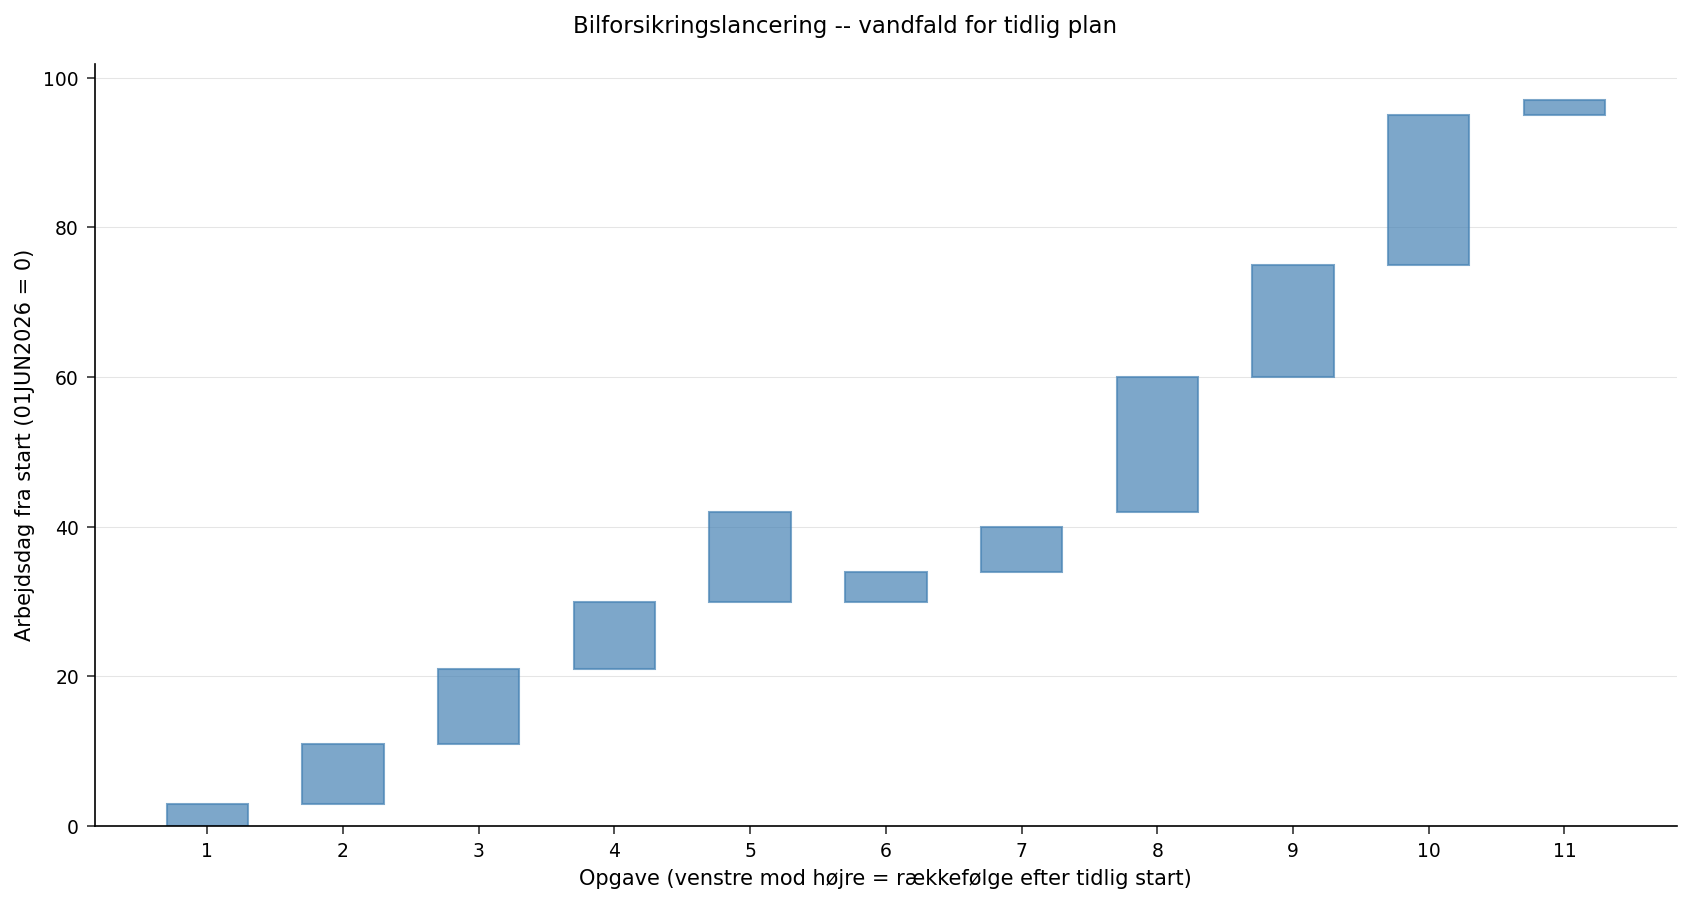

In [8]:
data gantt; SÆT sched_es;
   ord = es;          /* numerisk x = rækkefølge efter tidlig start */
KØR;
PROCEDURE SORTER data=gantt; EFTER ord activity; KØR;
data gantt; SÆT gantt; ax = _n_; KØR;   /* kompakt 1..11 x-indeks */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TITEL 'Bilforsikringslancering -- vandfald for tidlig plan';
PROCEDURE SGPLOT data=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS MÆRKAT='Opgave (venstre mod højre = rækkefølge efter tidlig start)'
         integer VALUES=(1 TIL 11 EFTER 1);
   YAXIS MÆRKAT='Arbejdsdag fra start (01JUN2026 = 0)' grid;
KØR;
ODS GRAPHICS OFF;

Læst fra venstre mod højre trapper søjlerne løbende op ad den kritiske kæde. De to opgaver, hvis søjler bryder trappen -- ved at starte lavere end toppen af den foregående søjle -- er takstindsendelse og godkendelse, de aktiviteter der bærer flydetid.

## Samlet flydetid pr. opgave

Ved at afbilde hver opgaves samlede flydetid bliver den kritiske vej umiskendelig: hver kritisk opgave ligger på nul, og kun de to regulatoriske opgaver hæver sig over den.

                                  Samlet flydetid pr. opgave (0 = på den kritiske vej)                                  




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Samlet flydetid pr. opgave (0 = på den kritiske vej).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


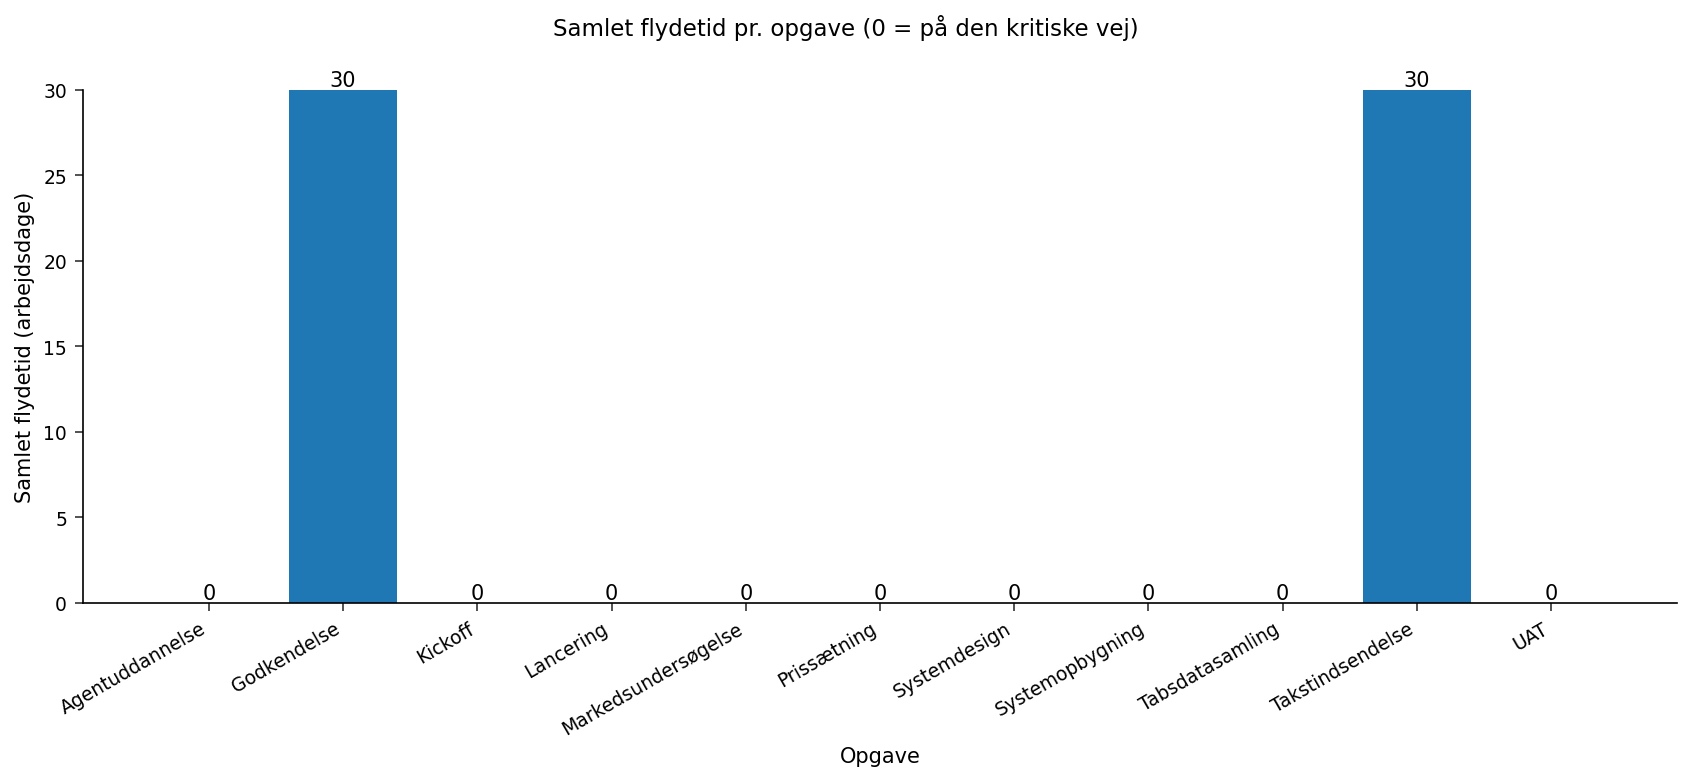

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TITEL 'Samlet flydetid pr. opgave (0 = på den kritiske vej)';
PROCEDURE SGPLOT data=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS MÆRKAT='Opgave' fitpolicy=rotatethin;
   YAXIS MÆRKAT='Samlet flydetid (arbejdsdage)';
KØR;
ODS GRAPHICS OFF;

## Ressourcebelastning under den tidlige plan

Ud over tidsplanen konkurrerer planen om to specialistpuljer. Ved at udfolde hver opgave over de arbejdsdage, den optager, og summere det daglige behov fremkommer ressourcebelastningsprofilen -- hvor mange aktuarer og udviklere planen kræver hver dag, hvis hver opgave starter så tidligt som muligt. Toppen er den største kapacitet, programmet nogensinde kræver på én gang.

                                   Maksimal daglig ressourcebelastning (tidlig plan)                                    

                                                  The MEANS Procedure

 Variable    Label         Maximum
 ---------------------------------
 ACTUARIES   Aktuarer            3
 DEVELOPERS  Udviklere           3
 ---------------------------------

                              Daglig aktuar- og udviklerbelastning under den tidlige plan                               




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Maksimal daglig ressourcebelastning (tidlig plan).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Daglig aktuar- og udviklerbelastning under den tidlige plan.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


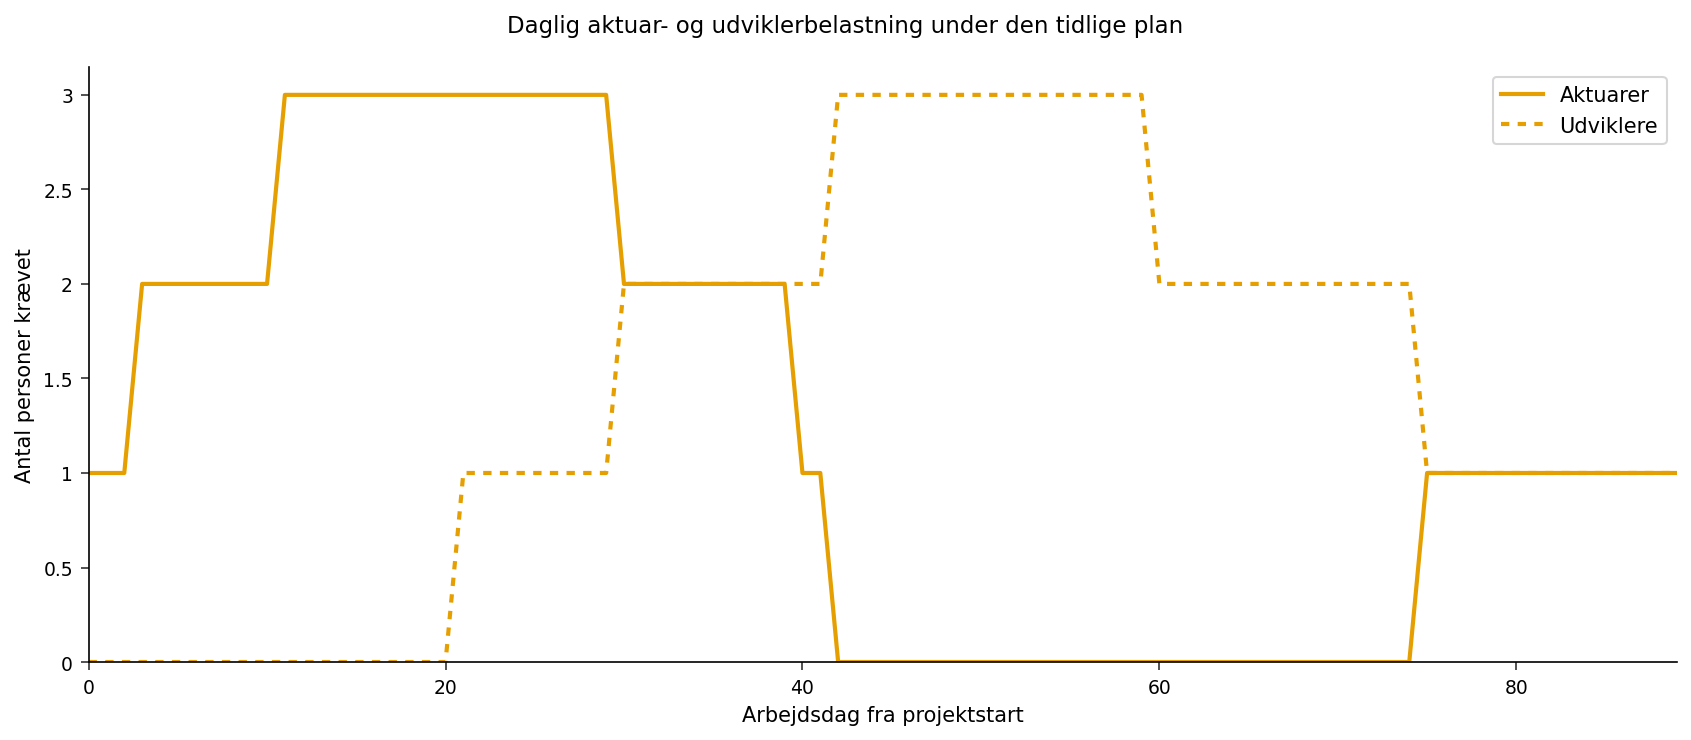

In [10]:
data LOAD;
   SÆT sched;
   GØR d = es TIL ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      UDDATA;
   SLUT;
   BEHOLD day a_use d_use;
KØR;

PROCEDURE GENNEMSNIT data=LOAD NOPRINT NWAY;
   KLASSE day;
   VARIABEL a_use d_use;
   UDDATA out=rprofile(FJERN=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
KØR;
PROCEDURE SORTER data=rprofile; EFTER day; KØR;

TITEL 'Maksimal daglig ressourcebelastning (tidlig plan)';
PROCEDURE GENNEMSNIT data=rprofile MAX maxdec=0;
   VARIABEL actuaries developers;
   MÆRKAT actuaries='Aktuarer' developers='Udviklere';
KØR;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TITEL 'Daglig aktuar- og udviklerbelastning under den tidlige plan';
PROCEDURE SGPLOT data=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Aktuarer';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Udviklere';
   XAXIS MÆRKAT='Arbejdsdag fra projektstart';
   YAXIS MÆRKAT='Antal personer krævet' MIN=0;
   keylegend / location=inside position=topright;
KØR;
ODS GRAPHICS OFF;

## Fortolkning af resultaterne

- **Lanceringsdatoen fastlægges af opbygningssporet, ikke det regulatoriske spor.** Den kritiske vej går Kickoff -> Markedsundersøgelse -> Samling af tabsdata -> Prissætning -> Systemdesign -> Systemopbygning -> UAT -> Agentuddannelse -> Lancering, med en makespan på 97 arbejdsdage (afsluttes 13OCT2026). Hver eneste af disse opgaver har nul flydetid, så enhver forsinkelse på dem skubber lanceringen dag for dag.

- **Den regulatoriske gren har en måneds slæk.** Takstindsendelse og godkendelse bærer hver 30 arbejdsdages samlet flydetid. Efter at prissætningen er afsluttet, kan de starte så sent som deres sene startdatoer og stadig nå at mødes med agentuddannelsen til tiden, fordi den parallelle systemopbygningsgren (systemdesign -> systemopbygning -> UAT) er den længste af de to veje, der fører til lanceringen. Planlægningsmæssigt er indsendelsen *ikke* den bindende begrænsning her -- det er opbygningen af policesystemet.

- **Specialistbehovet topper i forskellige faser.** Belastningsprofilen viser, at aktuarbehovet topper tidligt (frem til prissætning) og udviklerbehovet topper senere (frem til systemopbygningen), hver med et maksimum på tre personer om dagen. Fordi de to toppe falder i forskellige faser, kan et lille, sekventielt specialistteam bemande planen -- programmet behøver ikke sit maksimale antal aktuarer og udviklere samtidig.

**Forretningsmæssig pointe.** CPM omdanner en liste af lanceringsopgaver til en handlingsorienteret plan: den identificerer de aktiviteter på opbygningssporet, forsikringsselskabet skal beskytte for at nå 13OCT2026, kvantificerer den måneds slæk, der er til rådighed på den regulatoriske indsendelse, og viser, at forskudte aktuar- og udviklertoppe lader et slankt specialistteam levere planen.

*Implementeringsnote:* SAS beregner dette med PROC CPM (SAS/OR). Jenner når frem til det samme fremadrettede/bagudrettede kritiske vej-resultat med PROC OPTMODEL ved at løse de to længste vej-lineære programmer, der ligger til grund for metoden.